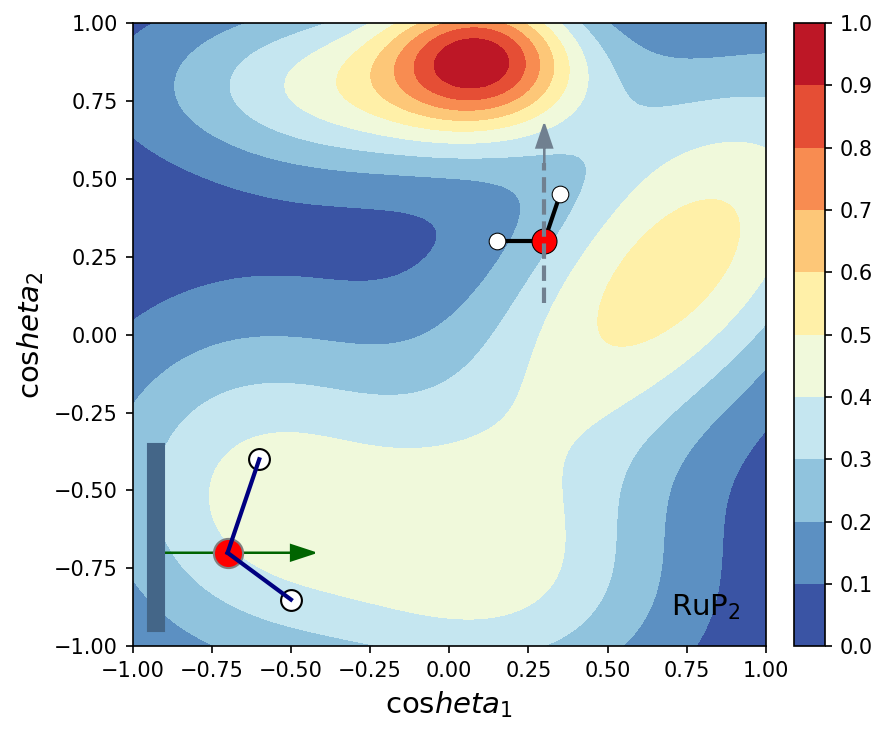

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
# Axes: cos(theta1) vs cos(theta2)
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)

# Probability Density Function (Mixture of Gaussians)
def gaussian_2d(x, y, x0, y0, sigmax, sigmay, theta=0):
    a = np.cos(theta)**2/(2*sigmax**2) + np.sin(theta)**2/(2*sigmay**2)
    b = -np.sin(2*theta)/(4*sigmax**2) + np.sin(2*theta)/(4*sigmay**2)
    c = np.sin(theta)**2/(2*sigmax**2) + np.cos(theta)**2/(2*sigmay**2)
    return np.exp( - (a*(x-x0)**2 + 2*b*(x-x0)*(y-y0) + c*(y-y0)**2))

# Create the organic shape
Z = np.zeros_like(X)
# Main arc
Z += 0.8 * gaussian_2d(X, Y, 0.7, 0.2, 0.3, 0.6, theta=np.pi/4)
Z += 0.7 * gaussian_2d(X, Y, -0.2, 0.8, 0.5, 0.2, theta=0)
Z += 0.6 * gaussian_2d(X, Y, -0.6, -0.5, 0.4, 0.4, theta=0) # Bottom left blob
Z += 0.5 * gaussian_2d(X, Y, 0.2, -0.8, 0.4, 0.3, theta=0) # Bottom right
Z += 0.9 * gaussian_2d(X, Y, 0.1, 0.9, 0.2, 0.15, theta=0) # Top spot

# Normalize
Z = Z / np.max(Z)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Contour Plot
# RdYlBu_r (Red-Yellow-Blue reversed)
levels = np.linspace(0, 1.0, 11)
cmap = plt.cm.RdYlBu_r
cntr = ax.contourf(X, Y, Z, levels=levels, cmap=cmap)

# Colorbar
cbar = fig.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
cbar.set_ticks(levels)

# Overlay Schematic (Water Molecule)
# Center O
ax.plot(0.3, 0.3, 'o', color='red', markersize=12, markeredgecolor='black', markeredgewidth=0.5)
# H atoms
ax.plot(0.15, 0.3, 'o', color='white', markersize=8, markeredgecolor='black', markeredgewidth=0.5)
ax.plot(0.35, 0.45, 'o', color='white', markersize=8, markeredgecolor='black', markeredgewidth=0.5)
# Bonds
ax.plot([0.15, 0.3], [0.3, 0.3], color='black', lw=2, zorder=1)
ax.plot([0.35, 0.3], [0.45, 0.3], color='black', lw=2, zorder=1)
# Dashed axis line
ax.plot([0.3, 0.3], [0.1, 0.55], color='slategray', linestyle='--', lw=2)
ax.arrow(0.3, 0.55, 0, 0.05, head_width=0.05, color='slategray')

# Overlay Schematic (Coordinate System, Bottom Left)
# O atom
ax.plot(-0.7, -0.7, 'o', color='red', markersize=14, markeredgecolor='gray')
# H atoms
ax.plot(-0.6, -0.4, 'o', color='white', markersize=10, markeredgecolor='black')
ax.plot(-0.5, -0.85, 'o', color='white', markersize=10, markeredgecolor='black')
# Bonds (Blue)
ax.plot([-0.7, -0.6], [-0.7, -0.4], color='navy', lw=2)
ax.plot([-0.7, -0.5], [-0.7, -0.85], color='navy', lw=2)
# Green Axes
ax.arrow(-0.9, -0.7, 0.4, 0, head_width=0.05, color='darkgreen') # Theta2 axis
# Surface (Blue Bar)
ax.add_patch(plt.Rectangle((-0.95, -0.95), 0.05, 0.6, color='#446688'))

# Styling
ax.set_xlabel(r'cos$	heta_1$', fontsize=14)
ax.set_ylabel(r'cos$	heta_2$', fontsize=14)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.text(0.7, -0.9, r'RuP$_2$', fontsize=14)

plt.tight_layout()
plt.show()
